In [1]:
from Soccer_OCEL.pass_feasibility import Player, PassEvent, make_grid, feasibility_map, evaluate_disk, rank_receivers, plot_feasibility_map, plot_component_breakdown, compute_feasibility_for_frame, get_k_enabled_passes, _log_feasible_passes, _log_enabled
import numpy as np
import pickle
import os
from Soccer_OCEL import utils
from Soccer_OCEL.idsse_import import get_games

In [2]:
path='data/28196177'
games=get_games(path)#load all 7 games
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}.pkl"), "rb") as f:
        GameData = pickle.load(f)
    GameData.settings.update({'xy_fields':(10,10)})
    GameData=_log_feasible_passes(GameData)
    #GameData=_log_enabled(GameData, encode=['role', 'name', 'zone', 'tuple', 'label'])
    with open(os.path.join('output','output_pkl',f"GameData_{Game}_enabled.pkl"), "wb") as f:
        pickle.dump(GameData, f)
    print(Game+' saved')

J03WMX saved
J03WN1 saved
J03WQQ saved
Skipping event OtherShot (idx=1874): Player 'DFL-OBJ-002FXT' not found in attacking team 'Away' at Session=2, Frame=35741. Players present: ['DFL-OBJ-00008F', 'DFL-OBJ-0000EJ', 'DFL-OBJ-0001HW', 'DFL-OBJ-0001LJ', 'DFL-OBJ-0026IA', 'DFL-OBJ-0028BZ', 'DFL-OBJ-0028T3', 'DFL-OBJ-002G68', 'DFL-OBJ-002FYC', 'DFL-OBJ-002G78', 'DFL-OBJ-002GG4']
J03WPY saved
Skipping event OtherShot (idx=426): Player 'DFL-OBJ-002GM1' not found in attacking team 'Away' at Session=1, Frame=26375. Players present: ['DFL-OBJ-0026UQ', 'DFL-OBJ-002651', 'DFL-OBJ-0027XP', 'DFL-OBJ-00268T', 'DFL-OBJ-0027B0', 'DFL-OBJ-002GNH', 'DFL-OBJ-0027VS', 'DFL-OBJ-002GAB', 'DFL-OBJ-0028SW', 'DFL-OBJ-002G2Y', 'DFL-OBJ-002GEE']
Skipping event OtherShot (idx=504): Player 'DFL-OBJ-0027XP' not found in attacking team 'Home' at Session=1, Frame=30843. Players present: ['DFL-OBJ-00003X', 'DFL-OBJ-0000NZ', 'DFL-OBJ-00006V', 'DFL-OBJ-0000F8', 'DFL-OBJ-J0130T', 'DFL-OBJ-00028V', 'DFL-OBJ-J014UG', 'DFL-

In [2]:
path='data/28196177'
Game='J03WR9'
with open(os.path.join('output','output_pkl',f"GameData_{Game}_enabled.pkl"), "rb") as f:
    GameData = pickle.load(f)
GameData.settings.update({'xy_fields':(10,10)})
#GameData=_log_feasible_passes(GameData)
#GameData.assign_roles_multi(team=True)
#GameData.format_log('ALL')

In [3]:
GameData.assign_roles_multi(process_DF='TEAMSHEET')


In [7]:
GameData=_log_enabled(GameData, encode=['role', 'name', 'zone', 'tuple', 'label', 'label', 'role:role', 'role:zone', 'role:side', 'role:player_position'])

In [ ]:
do a pass only log

queryign
if i am here and xx happened by far/just. what can i do?/what could have happened

In [22]:
np.unique(GameData.events[GameData.events['xG'].notna()]['eID'])

array(['BlockedShot', 'FreeKick_ShotAtGoal', 'Penalty_ShotAtGoal',
       'SavedShot', 'Scored', 'ShotAtGoal', 'ShotWide', 'ShotWoodWork'],
      dtype=object)

In [9]:
mask = GameData.events['eID'].str.contains('Pass|Cross', case=False, regex=True) & \
       ~GameData.events['eID'].str.contains('Received|Intercepted|Saved|Blocked|Wide|WoodWork', case=False, regex=True)
GameData.events[mask].iloc[3]['qualifier']

{'Player': 'DFL-OBJ-00008K',
 'Distance': 'short',
 'PlayOrigin': 'oppositionHalf',
 'FromOpenPlay': 'true',
 'FlatCross': 'false',
 'Recipient': 'DFL-OBJ-00003W',
 'PlayAngle': '306.44',
 'SemiField': 'false',
 'Team': 'DFL-CLU-00000P',
 'BallPossessionPhase': '11',
 'Evaluation': 'unsuccessful',
 'Height': 'high',
 'PenaltyBox': 'true',
 'FreeKickLayup': 'false'}

In [31]:
np.unique(GameData.events[GameData.events['BallPossessionPhase'].isna()]['eID'])

array(['BallDeflection', 'Caution', 'Foul', 'Nutmeg', 'Offside',
       'OutSubstitution', 'PenaltyNotAwarded', 'RefereeBall', 'Run',
       'SpectacularPlay', 'TacklingGame', 'ThrowIn',
       'VideoAssistantAction'], dtype=object)

In [20]:
e,s,f,p,t=GameData.events.iloc[2][['eID','Session','Frame', 'pID', 'Team']]

eID             Play_Pass
Session                 1
Frame                  77
pID        DFL-OBJ-0028FW
Team                 Home
Name: 2, dtype: object

In [ ]:
result = compute_feasibility_for_frame(
        tracking_df          = GameData.positions,
        team_sheets_df       = GameData.team_sheets_df,
        session              = s,
        frame                = f,
        attacking_team       = t,
        player_in_possession = p,
        fps                  = float(GameData.framerate),
        speed                = False,
    )

Receiver ranking (disk evaluation, Eq. 9)
  #1  DFL-OBJ-002GM9  score = 14.3067
  #2  DFL-OBJ-00028V  score = 11.3423
  #3  DFL-OBJ-J0130T  score = 8.6846
  #4  DFL-OBJ-00008K  score = 8.1246
  #5  DFL-OBJ-002FXT  score = 6.8857
  #6  DFL-OBJ-0000NZ  score = 4.7587
  #7  DFL-OBJ-002GMO  score = 3.0448
  #8  DFL-OBJ-002GM1  score = 0.9246
  #9  DFL-OBJ-J01KJ5  score = 0.6378
  #10  DFL-OBJ-0026RH  score = 0.1186



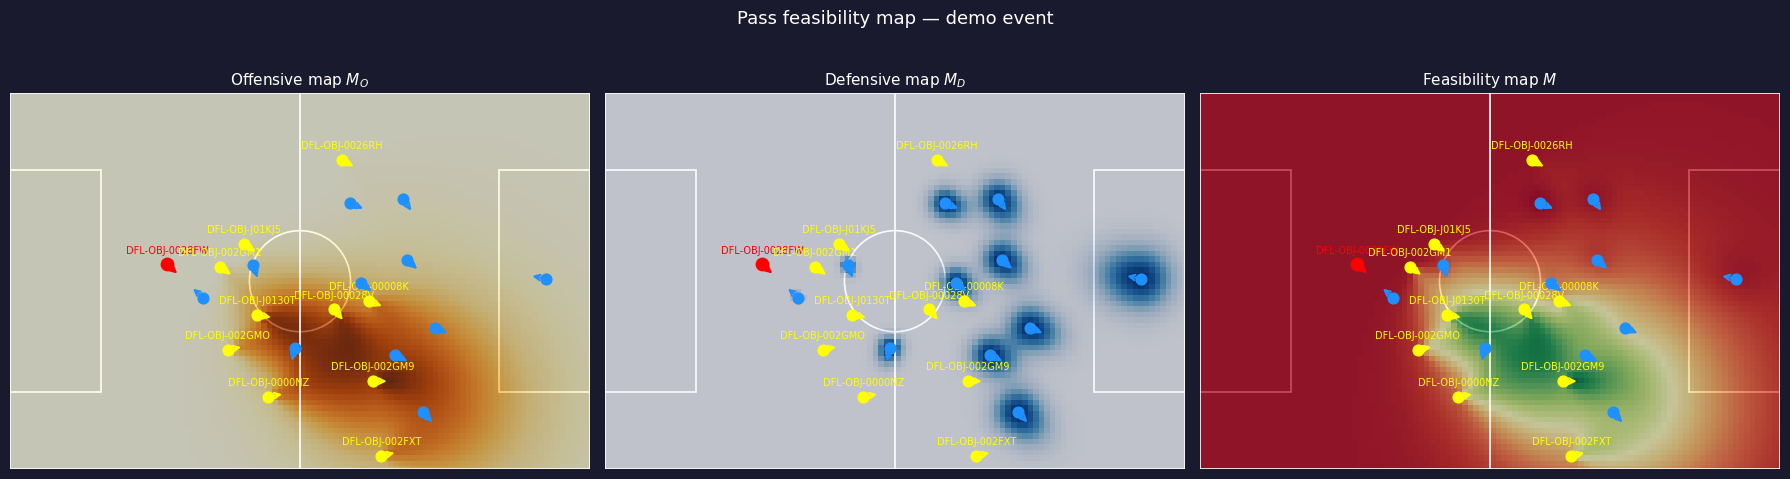

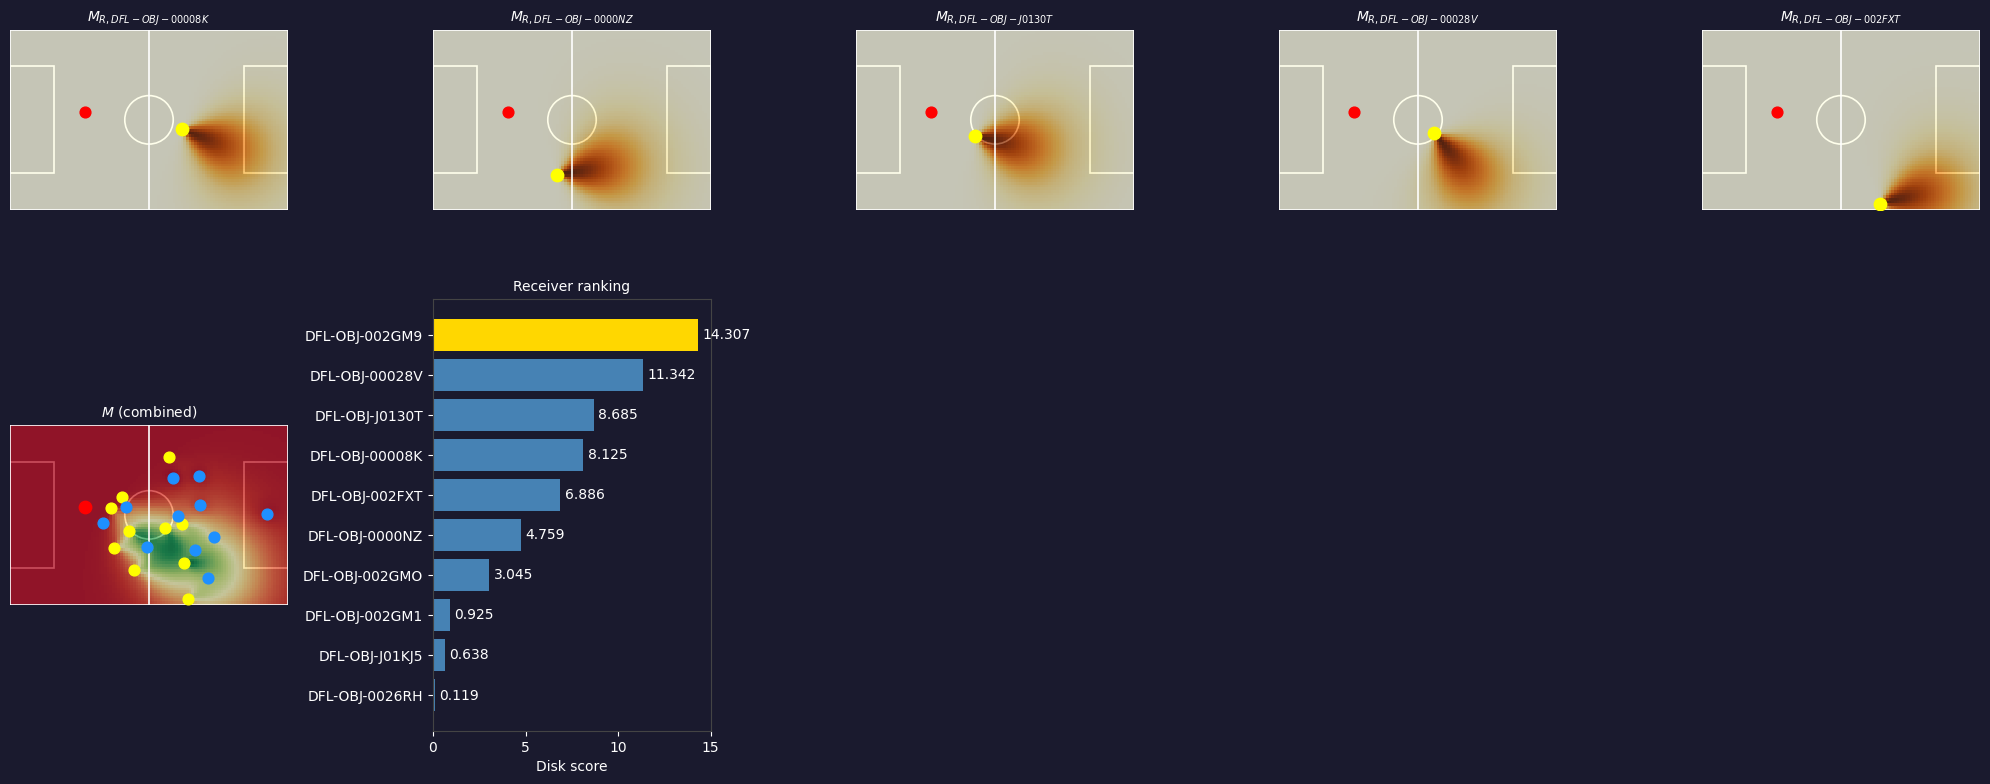

In [ ]:
print("=" * 50)
print("Receiver ranking (disk evaluation, Eq. 9)")
print("=" * 50)
for i, (score, r) in enumerate(result['ranked']):
    print(f"  #{i+1}  {r.name}  score = {score:.4f}")
print()


fig1 = plot_feasibility_map(result['event'], result['M'], result['MO'], result['MD'], result['X'], result['Y'], title="Pass feasibility map")

fig2 = plot_component_breakdown(result['event'], result['MO'], result['MD'], result['M'], result['X'], result['Y'], result['ranked'])